In [1]:
from langchain_openai import ChatOpenAI
from langchain.messages import HumanMessage,SystemMessage
from langchain_core.prompts import ChatPromptTemplate,PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_community.document_loaders import DirectoryLoader,PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma, FAISS
from langchain_openai import ChatOpenAI,OpenAIEmbeddings
from langgraph.graph import StateGraph,START, END,MessagesState
from typing import TypedDict,Annotated,Literal
import os 
import sys
sys.path.insert(1, r'D:\Notebooks\LLM\env')
from enviorment import load_env
from langgraph.prebuilt import ToolNode,tools_condition
from langchain_core.tools import tool
#from pydirectoryloader import rag_function
import os 
load_env()
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain.agents import create_agent
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_community.utilities import GoogleSerperAPIWrapper,WikipediaAPIWrapper
import logging
from langchain.agents.middleware import before_model, after_model
from langchain.agents.middleware import SummarizationMiddleware
#from langchain.middleware.summarization import SummarizationMiddleware
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
#from langchain_anthropic.middleware import anthropicPromptCachingMiddleware
from langchain.agents.middleware import TodoListMiddleware
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
from typing import TypedDict, List, Dict, Any

class RAGState(TypedDict):
    pdf_path: str
    doc_id: str
    tree: Dict[str, Any]
    node_map: Dict[str, Any]
    query: str
    relevant_nodes: List[str]
    retrieved_context: str
    final_answer: str

In [4]:
llm = ChatOpenAI(model="gpt-3.5-turbo", temperature=0)

In [3]:
api_key='5c55dcd133444b748d50d1255a622983'
PAGEINDEX_API_KEY = os.getenv("PAGEINDEX_API_KEY", "5c55dcd133444b748d50d1255a622983")
from pageindex import PageIndexClient

pi_client = PageIndexClient(api_key=PAGEINDEX_API_KEY)

In [31]:
def submit_document(state: RAGState):
    resp = pi_client.submit_document(state["pdf_path"])
    doc_id = resp.get("doc_id") or resp.get("id") or resp
    return {"doc_id": doc_id}
import time

def wait_for_index(state: RAGState):
    for _ in range(60):
        if pi_client.is_retrieval_ready(state["doc_id"]):
            return {}
        time.sleep(5)
    raise RuntimeError("Indexing timeout")
def fetch_tree(state: RAGState):
    tree_resp = pi_client.get_tree(state["doc_id"], node_summary=True)
    tree = tree_resp.get("result") if isinstance(tree_resp, dict) else tree_resp
    return {"tree": tree}
import pageindex.utils as utils

def build_node_map(state: RAGState):
    node_map = utils.create_node_mapping(state["tree"])
    return {"node_map": node_map}
import json
import asyncio

def llm_tree_search(state: RAGState):
    tree_without_text = utils.remove_fields(state["tree"].copy(), ["text"])

    # prompt = f"""
    # Question: {state['query']}
    # Tree:
    # {json.dumps(tree_without_text)}

    # Return:
    # {{
    #   "node_list": ["id1", "id2"]
    # }}
    # """
    search_prompt = f"""You are given a question and a tree structure of a document.
Each node contains a node id, node title, and a corresponding summary.
Your task is to find all nodes that are likely to contain the answer to the question.
Question: {state['query']}
Document tree structure:{json.dumps(tree_without_text, indent=2)}
Please reply in the following JSON format:{{
"thinking": "<Your thinking process on which nodes are relevant to the question>",
"node_list": ["node_id_1", "node_id_2"]}}
Directly return the final JSON structure. Do not output anything else.
"""
    print("Asking LLM to search the tree for relevant nodes...")

    result =  llm.invoke(search_prompt).content
    print ("LLM tree search result:", result)
    parsed = json.loads(result)

    return {"relevant_nodes": parsed["node_list"]}
def extract_context(state: RAGState):
    texts = []

    for nid in state["relevant_nodes"]:
        node = state["node_map"].get(nid)
        if not node:
            continue

        text = node.get("text", "")
        if isinstance(text, list):
            text = "\n".join(text)

        texts.append(text)

    return {"retrieved_context": "\n\n".join(texts)}
def generate_answer(state: RAGState):
    prompt = f"""
    Answer based only on context.

    Question: {state['query']}
    Context:
    {state['retrieved_context']}
    """

    answer =  llm.invoke(prompt).content
    return {"final_answer": answer}

In [32]:
from langgraph.graph import StateGraph, END

graph = StateGraph(RAGState)

graph.add_node("submit_document", submit_document)
graph.add_node("wait_for_index", wait_for_index)
graph.add_node("fetch_tree", fetch_tree)
graph.add_node("build_node_map", build_node_map)
graph.add_node("llm_tree_search", llm_tree_search)
graph.add_node("extract_context", extract_context)
graph.add_node("generate_answer", generate_answer)

graph.set_entry_point("submit_document")

graph.add_edge("submit_document", "wait_for_index")
graph.add_edge("wait_for_index", "fetch_tree")
graph.add_edge("fetch_tree", "build_node_map")
graph.add_edge("build_node_map", "llm_tree_search")
graph.add_edge("llm_tree_search", "extract_context")
graph.add_edge("extract_context", "generate_answer")
graph.add_edge("generate_answer", END)

app = graph.compile()

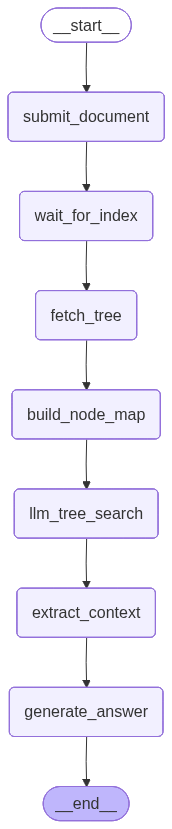

In [33]:
app

In [35]:
result = app.invoke({
    "pdf_path": "./data/pdf-test.pdf",
    "query": "What is this document about?"
})

print(result["final_answer"])

Asking LLM to search the tree for relevant nodes...
LLM tree search result: {
"thinking": "The document is titled 'PDF Test File' and contains information about a PDF reader and the Yukon Department of Education. Therefore, nodes related to PDF documents and the Yukon Department of Education are likely to contain information about what the document is about.",
"node_list": ["0000"]
}
This document is about informing the reader that their computer is equipped with a PDF reader and they should be able to view any PDF documents and forms available on the website of the Yukon Department of Education. It also provides the contact information for the department and their website URL.


In [ ]:
result

{'pdf_path': './data/pdf-test.pdf',
 'doc_id': 'pi-cmn0bwvco00r9fnpku6ze8ufs',
 'tree': [{'title': 'PDF Test File',
   'node_id': '0000',
   'page_index': 1,
   'summary': '# PDF Test File\n\nCongratulations, your computer is equipped with a PDF (Portable Document Format) reader! You should be able to view any of the PDF documents and forms available on our site. PDF forms are indicated by these icons: ▲ or ▼.\n\nYukon Department of Education\nBox 2703\nWhitehorse,Yukon\nCanada\nY1A 2C6\n\nPlease visit our website at: http://www.education.gov.yk.ca/\n',
   'text': '# PDF Test File\n\nCongratulations, your computer is equipped with a PDF (Portable Document Format) reader! You should be able to view any of the PDF documents and forms available on our site. PDF forms are indicated by these icons: ▲ or ▼.\n\nYukon Department of Education\nBox 2703\nWhitehorse,Yukon\nCanada\nY1A 2C6\n\nPlease visit our website at: http://www.education.gov.yk.ca/\n'}],
 'node_map': {'0000': {'title': 'PDF Te

: 